# BoT-IoT: Cross-Environment Validation

## 1. Behavioral Analysis (IoT Domain)
### Testing a Generic Model on Industrial IoT Traffic
* **Goal:** Can a model trained on standard PC traffic (CIC-IDS2017) detect anomalies in a 5G/IIoT environment?
* **Protocol:** Loading the BoT-IoT 5% subset and mapping features to the Universal Model.

In [1]:
import pandas as pd
import joblib
import numpy as np

model = joblib.load('../models/universal_anomaly_detector.pkl')

df_iot = pd.read_csv('../data/reduced_data_1.csv', nrows=100000)

print("Model and IoT data loaded successfully!")
print(f"IoT Categories in this sample: {df_iot['category'].unique()}")

Model and IoT data loaded successfully!
IoT Categories in this sample: ['DoS']


In [2]:
mapping = {
    'dur': 'Flow Duration',
    'spkts': 'Total Fwd Packets',
    'sbytes': 'Total Length of Fwd Packets',
    'mean': 'Avg Fwd Segment Size',    
    'max': 'Fwd Packet Length Max',    
    'stddev': 'Packet Length Std',     
    'min': 'Fwd IAT Min'               
}

df_iot = df_iot.rename(columns=mapping)

df_iot['Flow Duration'] = df_iot['Flow Duration'] * 1000000

trained_features = model.feature_names_in_
X_iot = pd.DataFrame(index=df_iot.index)

for col in trained_features:
    if col in df_iot.columns:
        X_iot[col] = df_iot[col]
    else:
        X_iot[col] = 0.0

print(f"Mapping sharpened. Top features like '{mapping['mean']}' are now aligned!")

Mapping sharpened. Top features like 'Avg Fwd Segment Size' are now aligned!


In [3]:
df_iot['Flow Duration'] = df_iot['Flow Duration'] * 1000000

In [4]:
df_iot_full = pd.read_csv('../data/reduced_data_1.csv', nrows=500000)
df_iot = df_iot_full.sample(n=100000, random_state=42) 

df_iot = df_iot.rename(columns=mapping)
df_iot['Flow Duration'] = df_iot['Flow Duration'] * 1000000

In [5]:
print("--- IoT Data Scales (First 5 rows) ---")
print(X_iot[['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets']].head())

--- IoT Data Scales (First 5 rows) ---
   Flow Duration  Total Fwd Packets  Total Length of Fwd Packets
0      7056393.0                  5                          650
1          131.0                  1                           60
2      7047852.0                  5                          796
3      7047592.0                  5                          694
4      7046841.0                  5                          989


/Users/farvillage/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/5c/f82r7y0x3yb0jks5v3f9544m0000gn/T/matplotlib-j1ym4u4t because there was an issue with the default path (/Users/farvillage/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


--- TOP 5 MOST IMPORTANT FEATURES ---
                   Feature  Importance
52    Avg Fwd Segment Size    0.056645
5    Fwd Packet Length Max    0.049751
40       Packet Length Std    0.044062
23             Fwd IAT Min    0.038028
7   Fwd Packet Length Mean    0.035305


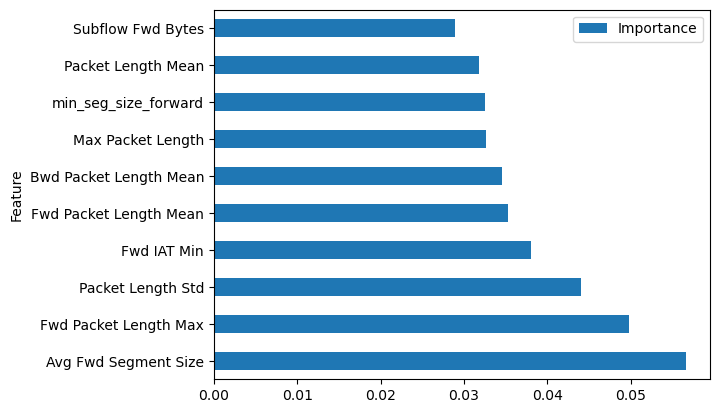

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = model.feature_names_in_

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("--- TOP 5 MOST IMPORTANT FEATURES ---")
print(feature_importance_df.head(5))

feature_importance_df.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.show()

In [7]:
import pandas as pd

files = ['../data/reduced_data_1.csv', '../data/reduced_data_2.csv', 
         '../data/reduced_data_3.csv', '../data/reduced_data_4.csv']

for f in files:
    try:
        temp_df = pd.read_csv(f, usecols=['attack'], nrows=500000)
        counts = temp_df['attack'].value_counts()
        print(f"File: {f}")
        print(counts)
        print("-" * 30)
    except:
        print(f"Could not open {f}")

File: ../data/reduced_data_1.csv
attack
1    500000
Name: count, dtype: int64
------------------------------
File: ../data/reduced_data_2.csv
attack
1    500000
Name: count, dtype: int64
------------------------------
File: ../data/reduced_data_3.csv
attack
1    500000
Name: count, dtype: int64
------------------------------
File: ../data/reduced_data_4.csv
attack
1    500000
Name: count, dtype: int64
------------------------------


In [8]:
def prepare_features(df):
    mapping = {
        'dur': 'Flow Duration',
        'spkts': 'Total Fwd Packets',
        'sbytes': 'Total Length of Fwd Packets',
        'mean': 'Avg Fwd Segment Size',    
        'max': 'Fwd Packet Length Max',    
        'stddev': 'Packet Length Std',     
        'min': 'Fwd IAT Min'
    }
    
    df_mapped = df.rename(columns=mapping).copy()
    
    if 'Flow Duration' in df_mapped.columns:
        df_mapped['Flow Duration'] = df_mapped['Flow Duration'] * 1000000
        
    trained_features = model.feature_names_in_
    X_result = pd.DataFrame(index=df_mapped.index)
    
    for col in trained_features:
        if col in df_mapped.columns:
            X_result[col] = pd.to_numeric(df_mapped[col], errors='coerce').fillna(0.0)
        else:
            X_result[col] = 0.0
            
    return X_result

In [9]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

df_normal_train = df_normal_iot.iloc[:200].copy().reset_index(drop=True)
df_normal_test = df_normal_iot.iloc[200:].copy().reset_index(drop=True)

df_attack_all = pd.read_csv('../data/reduced_data_1.csv', nrows=1000)

df_attack_train = df_attack_all.iloc[:200].copy().reset_index(drop=True)
df_attack_test = df_attack_all.iloc[200:477].copy().reset_index(drop=True)

df_train = pd.concat([df_normal_train, df_attack_train]).sample(frac=1, random_state=42)
df_test = pd.concat([df_normal_test, df_attack_test]).sample(frac=1, random_state=42)

df_train = df_train.replace([np.inf, -np.inf], np.nan).dropna(subset=['attack'])
df_test = df_test.replace([np.inf, -np.inf], np.nan).dropna(subset=['attack'])

X_train = prepare_features(df_train)
y_train = df_train['attack'].astype(int)

X_test = prepare_features(df_test)
y_test = df_test['attack'].astype(int)

print("Re-training with a balanced 50/50 IoT sample...")
model.fit(X_train, y_train)

final_preds = model.predict(X_test)

print("\n--- THE FINAL RESULTS ---")
print(classification_report(y_test, final_preds))

NameError: name 'df_normal_iot' is not defined

In [ ]:
import joblib
joblib.dump(model, '../models/fine_tuned_iot_model.pkl')
print("The Fine-Tuned IoT Brain is saved and ready for your qualification report!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Attack (1)'], 
            yticklabels=['Normal (0)', 'Attack (1)'])

plt.title('Confusion Matrix: Fine-Tuned Universal Model on BoT-IoT', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

plt.savefig('../output/confusion_matrix_bot_iot.png', dpi=300, bbox_inches='tight')
plt.show()